In [329]:
#### old function ####

import numpy as np
from scipy.stats import rice
from scipy.special import i1
from scipy.special import i0

### Pointing error and turbulence affected transmissivity
'''
parameter definitions:
lam: wavelength of light 
w_0: initial waist of beam (0.8 is the filling fraction)
a_r: receiver telescope radius
a_t: transmitting telescope radius
eff_r: receiver detector efficiency (both local and remote detectors are considered equally inefficient)
eff_t: transmitter detector efficiency
z: link length
beta: atmospheric extinction coefficient for lam = 800 nm


important terms:
z_r: Rayleigh range
secZ: secant of the zenith angle (used to determine the slant range)
Cn2: atmospheric refractive index structure constant (defined using the Hufnagel-Valley model)
w_st: short-term beam waist size, as broadened by short time scale turbulence (beam broadening)
sigma_tb: std. dev. of random deflections by long-time scale (10-100 ms) turbulence (beam wandering)
sigma_p: std. dev of random deflections from pointing error
mean_p_err: mean of random deflections (radially away from the center of the receiving telescope)
eta_atm: atmospheric attenuation
eta_r: output of eta_rand function - random transmissivity for a given deflection (r - metres)
eta: output of eta_avg function - average transmissivity (averaged over deflections chosen from a Rice distribution)
'''

def eta_rand_old(r, z, h, lam, a_t, a_r, eff_t, eff_r):
    
    # standard beam broadening
    lam = 810e-9
    k = 2*np.pi/lam
    w_0 = 0.8*a_t    # initial waist of optical beam
    z_r = np.pi*(w_0**2)/lam  #Rayleigh range
    w_z = np.sqrt((w_0**2)*(1+(z/z_r)**2)) 

    # atmospheric attenuation 
    secZ = 1 / ((h / z) - (z**2 - h**2) / (2 * a_r * z))
    beta = 0.22
    eta_atm = np.exp(- beta * secZ)
    
    # turbulence effects
    # Cn2 = 7.08*10**(-14) #day-time value at 20 m altitude
    # Cn2 = 4.91*10**(-15) #night-time value at 20 m altitude
    Cn2 = 10**-16 #7.95*10**(-18) #avg cn2
    rho_0 = (0.548*k**2*Cn2*z)**(-3/5)
    phi = 0.33*(rho_0/w_0)
    w_st = np.sqrt((w_z**2) + 2*((1-phi)**2)*(lam*z/(np.pi*rho_0))**2)
    sigma_tb = np.sqrt((0.1337*(lam**2)*(z**2))/(((w_0)**(1/3))*(rho_0**(5/3))))

    eta_st = 1-np.exp(-(2*a_r**2)/(w_st**2))  #short-term beam broadened transmissivity 
    eta_far = 2*(a_r**2)/(w_st**2)        #far-range transmissivity (short-term)
    eta_0 = eta_st*eta_atm*eff_t*eff_r   #total transmissivity without beam wandering effects

    # beam wandering effects

    lb_0 = np.exp(-2*eta_far)*i0(2*eta_far)
    lb_1 = np.exp(-2*eta_far)*i1(2*eta_far)
    gm = ((4*eta_far*lb_1)/(1-lb_0))*(np.log((2*eta_st)/(1-lb_0)))**(-1)
    r_0 = a_r*(np.log((2*eta_st)/(1-lb_0)))**(-1/gm)

    eta_r = eta_0*np.exp(-(r/r_0)**gm)
    
    return eta_r

def eta_avg_old(z, h, a_t, a_r, eff_t, eff_r):
    # standard beam broadening
    lam = 810e-9
    k = 2*np.pi/lam
    w_0 = 0.8*a_t
    z_r = np.pi*(w_0**2)/lam  #Rayleigh range
    w_z = np.sqrt((w_0**2)*(1+(z/z_r)**2))
    print(z,w_z)
    # turbulence effects
    # Cn2 = 7.08*10**(-14) #day-time value at 20 m altitude
    # Cn2 = 4.91*10**(-15) #night-time value at 20 m altitude
    Cn2 = 10**-16 #7.95*10**(-18) #avg cn2
    rho_0 = (0.548*k**2*Cn2*z)**(-3/5)
    phi = 0.33*(rho_0/w_0)
    w_st = np.sqrt((w_z**2) + 2*((1-phi)**2)*(lam*z/(np.pi*rho_0))**2)
    sigma_tb = np.sqrt((0.1337*(lam**2)*(z**2))/(((w_0)**(1/3))*(rho_0**(5/3))))

    # pointing error
    mean_p_err = 0 #1e-5
    sigma_p = z*1e-6
    
    s = np.sqrt(sigma_tb**2 + sigma_p**2)  #total beam wandering
    
    r_list = rice.rvs(mean_p_err/s, scale=s, size=10000) #list of random deflections following a Rice distribution (Rayleigh with non-zero mean)
    # r_list = np.zeros([100,1])
    eta = np.mean(eta_rand_old(r_list, z, h, lam, a_t, a_r, eff_t, eff_r))
    # print(s)

    return eta



In [355]:
#### correct layered function ####

import numpy as np
from scipy.stats import rice
from scipy.special import i1
from scipy.special import i0

def Cn2_h(h):
    return 5.94e-53*(21/27)**2*h**10*np.exp(-h/1000) + 2.7e-16*np.exp(-h/1500) + 1.7e-14*np.exp(-h/100)
    
### Pointing error and turbulence affected transmissivity
'''
parameter definitions:
r: random deflection from rice distribution
lam: wavelength of light 
w_0: initial waist of beam (0.8 is the filling fraction)
a_r: receiver telescope radius
a_t: transmitting telescope radius
eff_r: receiver detector efficiency (both local and remote detectors are considered equally inefficient)
eff_t: transmitter detector efficiency
z: link length
beta: atmospheric extinction coefficient for lam = 800 nm


important terms:
z_r: Rayleigh range
Cn2: atmospheric refractive index structure constant (defined using the Hufnagel-Valley model)
w_st: short-term beam waist size, as broadened by short time scale turbulence (beam broadening)
sigma_tb: std. dev. of random deflections by long-time scale (10-100 ms) turbulence (beam wandering)
sigma_p: std. dev of random deflections from pointing error
mean_p_err: mean of random deflections (radially away from the center of the receiving telescope)
eta_atm: atmospheric attenuation
eta_r: output of eta_rand function - random transmissivity for a given deflection (r - metres)
eta: output of eta_avg function - average transmissivity (averaged over deflections chosen from a Rice distribution)
'''

def eta_rand(r, z, H, zen_ang, lam, a_t, a_r, eff_t, eff_r, link):
    
    # standard beam broadening
    lam = 810e-9
    k = 2*np.pi/lam
    w_0 = 0.8*a_t    # initial waist of optical beam
    z_r = np.pi*(w_0**2)/lam  #Rayleigh range
    # w_z = np.sqrt((w_0**2)*(1+(z/z_r)**2)) 

    # atmospheric attenuation 
    secZ = 1 / ((H / z) - (z**2 - H**2) / (2 * a_r * z))
    beta = 0.22
    eta_atm = np.exp(- beta * secZ)

    # turbulence effects
    N_layers = 2000
    h_max = 20e3
    h   = np.linspace(0, h_max, N_layers)  # [m]
    dh  = h[1] - h[0]
    
    # slant geometry
    ds  = dh / np.cos(zen_ang)
    L   = h_max / np.cos(zen_ang)

    #Cn2 for each layer
    Cn2 = Cn2_h(h)
    
    # Rytov variance (scintillation)
    integrand_R = Cn2 * (L - h)**(5/6) #symmetric under uplink/downlink
    σ_R2 = 1.23 * k**(7/6) * np.sum(integrand_R * ds)
    
    if link=='up':
    
        w_st_atm   = w_0 * np.sqrt(1 + (L/z_r)**2)
        w_eff_atm  = w_st_atm * np.sqrt(1 + σ_R2)
        L_vac      = z - L
        z_r_eff    = np.pi*(w_eff_atm**2)/lam
        w_st       = w_eff_atm * np.sqrt(1 + (L_vac/z_r_eff)**2)

    if link=='down':
        
        # vacuum diffraction up to top of turbulence
        L_vac = z - L
        w_st_vac  = w_0 * np.sqrt(1 + (L_vac/z_r)**2)

        z_r_eff   = np.pi*(w_st_vac**2)/lam
        w_st_atm  = w_st_vac * np.sqrt(1 + (L/z_r_eff)**2)
        
        # turbulence broadening in atmosphere
        w_st  = w_st_atm * np.sqrt(1 + σ_R2)


    eta_st = 1-np.exp(-(2*a_r**2)/(w_st**2))  #short-term beam broadened transmissivity 
    eta_far = 2*(a_r**2)/(w_st**2)        #far-range transmissivity (short-term)
    
    eta_0 = eta_st*eta_atm*eff_t*eff_r   #total transmissivity without beam wandering effects
    # beam wandering effects

    lb_0 = np.exp(-2*eta_far)*i0(2*eta_far)
    lb_1 = np.exp(-2*eta_far)*i1(2*eta_far)
    gm = ((4*eta_far*lb_1)/(1-lb_0))*(np.log((2*eta_st)/(1-lb_0)))**(-1)
    r_0 = a_r*(np.log((2*eta_st)/(1-lb_0)))**(-1/gm)

    eta_r = eta_0*np.exp(-(r/r_0)**gm)
    return eta_r

def eta_avg(z, H, zen_ang, a_t, a_r, eff_t, eff_r, link):

    # pointing error
    mean_p_err = 0 #1e-5
    sigma_p = z*1e-6

    lam = 810e-9
    k = 2*np.pi/lam

    N_layers = 2000
    h_max = 20e3
    h   = np.linspace(0, h_max, N_layers)  # [m]
    dh  = h[1] - h[0]
    
    # slant geometry
    ds  = dh / np.cos(zen_ang)
    L   = h_max / np.cos(zen_ang)

    #Cn2 for each layer
    Cn2 = Cn2_h(h)

    # beam‐wandering variance due to turbulence
    # Uplink wander variance
    if link=='up':
        σ_tb_sq = 2.42 * k**2 * np.sum(Cn2 * ((L - h)/L)**(5/3) * ds)

    # Downlink wander variance
    if link=='down':
        σ_tb_sq = 2.42 * k**2 * np.sum(Cn2 * (h/L)**(5/3) * ds)

    # Rytov variance (scintillation)
    integrand_R = Cn2 * (L - h)**(5/6) #symmetric under uplink/downlink
    σ_R2 = 1.23 * k**(7/6) * np.sum(integrand_R * ds)

    # scintillation gain (twinkling)
    var_ln = np.log(1 + σ_R2)
    G = np.random.lognormal(-0.5*var_ln, np.sqrt(var_ln))
    
    s = np.sqrt(σ_tb_sq + sigma_p**2)  #total beam wandering
    print(link,'sigma_turb=',np.sqrt(σ_tb_sq))
    
    r_list = rice.rvs(mean_p_err/s, scale=s, size=100000) #list of random deflections following a Rice distribution (Rayleigh with non-zero mean)

    eta = np.mean(eta_rand(r_list, z, H, zen_ang, lam, a_t, a_r, eff_t, eff_r, link))
    
    return eta
    

In [356]:
###oldest function ###

def eta_old(L, h, r, R, eff):
    
    lam = 810e-9;
    sigma = 0;

    secZ = 1 / ((h / L) - (L**2 - h**2) / (2 * R * L));

    w0 = .8 * r;  # initial waist of optical beam

    theta_d = lam / (np.pi * w0);  # beam divergence angle

    wL = (w0**2 + (theta_d**2 + sigma**2) * (L**2))**0.5;  # beam waist at receiving OGS, a distance L away from transmitter
    
    eta_sg = 1 - np.exp(-2 * R**2 / wL**2);  # diffraction-lim transmittance
    # print('old',wL,eta_sg)
    # atmospheric attenuation 
    beta = 0.22
    eta_atm = np.exp(- beta * secZ)

    efficiency = eta_sg * eff * eff * eta_atm;
    
    return efficiency


In [357]:
#helper functions for running dynamics of eta

import numpy as np
import math 
import random
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm

def generate_rotation(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz

    return np.matrix(expm(angle * L))

def generate_rotation_approx(axis, angle):

    # Last modified: 13 March 2019

    """
    Generates the rotation matrix about the given axis (unit vector in Cartesian coordinates) by the given angle.
    """

    # Generators of the SO(3) rotations
    Lx = np.matrix([[0, 0, 0], [0, 0, -1], [0, 1, 0]])
    Ly = np.matrix([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
    Lz = np.matrix([[0, -1, 0], [1, 0, 0], [0, 0, 0]])

    n1 = axis[0]
    n2 = axis[1]
    n3 = axis[2]

    L = n1 * Lx + n2 * Ly + n3 * Lz
    
    M = np.identity(3) + angle*L #+ 0.5*(angle**2)*L*L 

    return np.matrix(M)

def evolve_vector(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def evolve_vector_approx(init_point, axis, omega, T):

    """
    Performs rotation of a given initial point (init_point, in Cartesian coordinates) by the given axis
    (unit vector in Cartesian coordinates) at a given rotation speed (omega) for a time T (starting at t = 0).
    """

    init_point = np.matrix(init_point).H

    R = generate_rotation_approx(axis, omega * T)
    point_t = R * init_point

    point_t_x = np.array(point_t[0])[0][0]
    point_t_y = np.array(point_t[1])[0][0]
    point_t_z = np.array(point_t[2])[0][0]

    return [point_t_x, point_t_y, point_t_z]

def generate_point(R, theta, phi):

    """
    Generates (in Cartesian coordinates) the point in 3D specified by
    the spherical coordinates R, theta, phi
    Here, phi is the azimuthal angle (positive going counter-clockwise from the positive x-axis), and
    theta is the polar angle (positive going down from the z-axis)
    """

    return [R * np.sin(theta) * np.cos(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(theta)]

def dst(a, b):
    
    return ((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)**0.5


In [365]:
#Trial run for two ground stations

c = 2.9978e8
R = 6371e3
h = 500e3
G = 6.67408e-11
M = 5.972e24
om = (G*M/(R+h)**3)**0.5
Om = 2*np.pi/24/3600

r_gs = 0.6
r_sat = 0.1
eff_gs = 0.5
eff_sat = 0.5

#two ground stations
gs1_0 = generate_point(R, 90*np.pi/180, -2*np.pi/180)
gs2_0 = generate_point(R, 90*np.pi/180, 2*np.pi/180)

axis_earth = np.array([0,0,1]) #z-axis


#satellite
sat_0 = generate_point(R+h, 80*np.pi/180, 0*np.pi/180)

axis_sat = np.array([0,1,0]) #x-axis

T_big = 300
dT = 1
bigsteps = math.floor(T_big/dT)

eff_gs1_sat = []
eff_sat_gs1 = []
eff_gs2_sat = []
eff_sat_gs2 = []
dist1_all=[]

eff_gs1_sat_old = []
eff_sat_gs1_old = []
eff_gs2_sat_old = []
eff_sat_gs2_old = []

for t_gb in range(bigsteps):
    print(t_gb)
    gs1 = evolve_vector(gs1_0, axis_earth, Om, t_gb*dT)
    gs2 = evolve_vector(gs2_0, axis_earth, Om, t_gb*dT)
    sat = evolve_vector(sat_0, axis_sat, om, t_gb*dT)

    #gs velocities
    v_gs1 = np.cross(gs1, Om*axis_earth)
    v_gs2 = np.cross(gs2, Om*axis_earth)
    
    #satellite velocity
    v_sat = np.cross(sat, om*axis_sat)
    
    #radial relative velocities
    v_rel_radial1 = np.dot(np.subtract(v_sat, v_gs1), np.subtract(sat, gs1)/np.linalg.norm(np.subtract(sat, gs1)))
    v_rel_radial2 = np.dot(np.subtract(v_sat, v_gs2), np.subtract(sat, gs2)/np.linalg.norm(np.subtract(sat, gs2)))
    
    angle1  = math.acos(np.dot(gs1,np.subtract(sat,gs1))/np.linalg.norm(gs1)/np.linalg.norm(np.subtract(sat,gs1)))
    angle2  = math.acos(np.dot(gs2,np.subtract(sat,gs2))/np.linalg.norm(gs2)/np.linalg.norm(np.subtract(sat,gs2)))
    
    dist1 = dst(gs1, sat)
    dist2 = dst(gs2, sat)
    

    if angle1*180/np.pi<80:
        print(angle1*180/np.pi)
        eff_gs1_sat.append(-10*np.log10(eta_avg(dist1, h, angle1, r_gs, r_sat, eff_gs, eff_sat,'up')))
        eff_sat_gs1.append(-10*np.log10(eta_avg(dist1, h, angle1, r_sat, r_gs, eff_gs, eff_sat,'down')))
        eff_gs1_sat_old.append(-10*np.log10(eta_avg_old(dist1, h, r_gs, r_sat, eff_gs, eff_sat)))
        eff_sat_gs1_old.append(-10*np.log10(eta_avg_old(dist1, h, r_sat, r_gs, eff_gs, eff_sat)))
        dist1_all.append(dist1)
        
    else:
        eff_gs1_sat.append(0)
        eff_sat_gs1.append(0)
        eff_gs1_sat_old.append(0)
        eff_sat_gs1_old.append(0)
        dist1_all.append(dist1)
        
    if angle2*180/np.pi<80: 
        print(angle2*180/np.pi)
        eff_gs2_sat.append(-10*np.log10(eta_avg(dist2, h, angle2, r_gs, r_sat, eff_gs, eff_sat,'up')))
        eff_sat_gs2.append(-10*np.log10(eta_avg(dist2, h, angle2, r_sat, r_gs, eff_gs, eff_sat,'down')))
        eff_gs2_sat_old.append(-10*np.log10(eta_avg_old(dist2, h, r_gs, r_sat, eff_gs, eff_sat)))
        eff_sat_gs2_old.append(-10*np.log10(eta_avg_old(dist2, h, r_sat, r_gs, eff_gs, eff_sat)))
    
    else:
        eff_gs2_sat.append(0)
        eff_sat_gs2.append(0)
        eff_gs2_sat_old.append(0)
        eff_sat_gs2_old.append(0)


0
72.15788032456643
up sigma_turb= 32.834991417284165
down sigma_turb= 1.9494929095215496
1277735.7011941168 0.8375279765096167
1277735.7011941168 4.118775547624142
72.15788032456643
up sigma_turb= 32.834991417284165
down sigma_turb= 1.9494929095215496
1277735.7011941168 0.8375279765096167
1277735.7011941168 4.118775547624142
1
71.99778460936638
up sigma_turb= 32.6902854497355
down sigma_turb= 1.9551153012232891
1271062.9460296016 0.834593296433423
1271062.9460296016 4.097274086055003
72.00193441840523
up sigma_turb= 32.69401124825319
down sigma_turb= 1.954970036284505
1271235.1259230473 0.8346689574456885
1271235.1259230473 4.09782889672629
2
71.83635024009355
up sigma_turb= 32.54636723586764
down sigma_turb= 1.960747026829872
1264396.998906399 0.8316666944034408
1264396.998906399 4.075794604844319
71.84477226570677
up sigma_turb= 32.55382655293873
down sigma_turb= 1.9604541471195065
1264743.2172301975 0.831818571335584
1264743.2172301975 4.076910212682613
3
71.6735577137696
up sigma_

In [366]:
import numpy as np

# 1) layer setup
elevation = 85          # degrees at best pass
zenith    = np.radians(90-elevation)
h_atm     = 20e3        # only integrate to 20 km
N         = 2000
h         = np.linspace(0, h_atm, N)
dh        = h[1] - h[0]
ds        = dh / np.cos(zenith)
L         = h_atm / np.cos(zenith)

# 2) HV profile
A = 1.7e-14
def Cn2_HV(h):
    term1 = 0.00594*(21/27)**2*(1e-5*h)**10*np.exp(-h/1000)
    term2 = 2.7e-16*np.exp(-h/1500)
    term3 = A*np.exp(-h/100)
    return term1 + term2 + term3

Cn2 = Cn2_HV(h)

# 3) wander calculation
wavelength = 800e-9
k          = 2*np.pi / wavelength
weights_u  = ((L - h)/L)**(5/3)      # dimensionless!
sigma2     = 2.42 * k**2 * np.sum(Cn2 * weights_u * ds)
sigma_u    = np.sqrt(sigma2)

print(f"Uplink σ_bw = {sigma_u:.2f} m")


Uplink σ_bw = 18.03 m


Text(0.5, 1.0, 'downlinks')

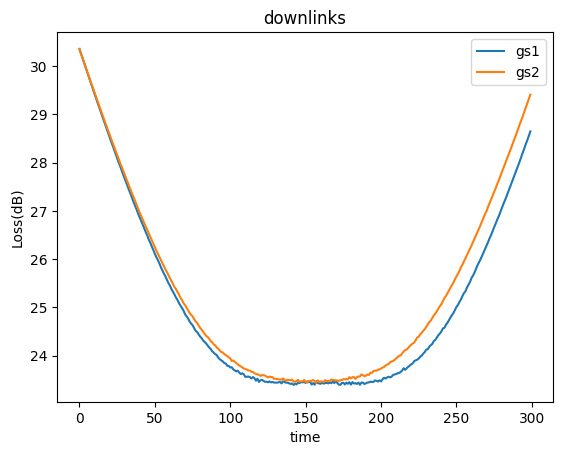

In [371]:
plt.plot(eff_sat_gs1)
plt.plot(eff_sat_gs2)

# plt.plot(eff_sat_gs1_old)
# plt.plot(eff_sat_gs2_old)

plt.ylabel('Loss(dB)')
plt.xlabel('time')
plt.legend(['gs1','gs2', 'gs1old', 'gs2old'])
plt.title('downlinks')

Text(0.5, 1.0, 'uplinks')

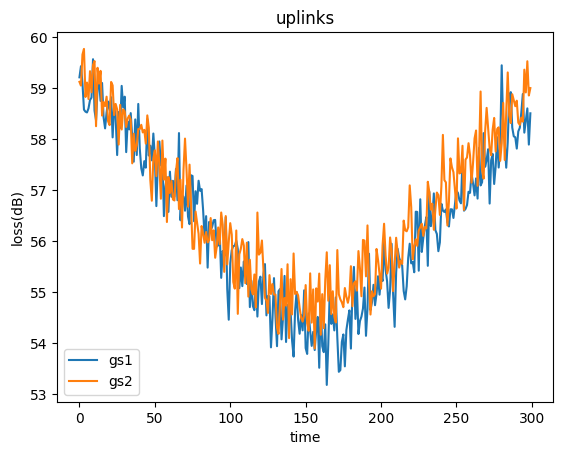

In [372]:
plt.plot(eff_gs1_sat)
plt.plot(eff_gs2_sat)
# plt.plot(eff_gs1_sat_old)
# plt.plot(eff_gs2_sat_old)

plt.ylabel('loss(dB)')
plt.xlabel('time')
plt.legend(['gs1','gs2', 'gs1old', 'gs2old'])
plt.title('uplinks')